# ARTI 406 Final Project
# Early Diabetes Prediction

In [1]:

#import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

## 1. Exploratory Data Analysis (EDA)

### 1.1 Dataset Overview

In [2]:
# Load dataset
df = pd.read_csv("diabetes.csv")

# Display first rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

### 1.2 Missing Value Analysis

In [4]:
# Dataset shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Dataset information
df.info()

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Display statistical summary
df.describe()

Number of rows: 768
Number of columns: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
Di

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### **Dataset Structure**
The dataset contains 768 records and 9 columns.

There are 8 input features and 1 target variable (Outcome).

The target variable is binary:

- 0 = Non-diabetic
- 1 = Diabetic

### **Data Types**
The dataset consists of:
- 7 integer features
- 2 floating-point features (BMI and DiabetesPedigreeFunction)
All features are numerical, which makes them suitable for machine learning algorithms without requiring categorical encoding.

### **Missing Values**
The initial missing value analysis showed no explicit missing values (NaN) in any column.
However, the descriptive statistics revealed several features with minimum values equal to 0, including:
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI

Since these measurements cannot realistically be zero for a living patient, these values were treated as invalid and handled during preprocessing.

### **Statistical Observations**
- The average age of patients is approximately 33 years.
- The average glucose level is approximately 121 mg/dL.
- The average BMI is approximately 32, indicating that many patients fall within the overweight or obese range.
- The Insulin feature exhibits very high variability (standard deviation ≈ 115), suggesting the presence of extreme values or outliers.
- The Outcome mean is 0.349, indicating that approximately 35% of patients are diabetic and 65% are non-diabetic

### 1.3 Data Cleaning

In [5]:
# Columns where 0 is considered invalid / missing
zero_missing_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Count zeros in these columns
zero_counts = (df[zero_missing_cols] == 0).sum()

print(zero_counts)

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


These values were considered invalid because measurements such as glucose level, blood pressure, skin thickness, insulin concentration, and BMI cannot realistically be zero for a living patient.

The number of invalid zero values identified was:

Glucose = 5

BloodPressure  =   35

SkinThickness  =  227

Insulin     =     374

BMI         =      11

The Insulin feature contained the highest number of invalid values, with nearly half of its observations recorded as zero. This indicates a substantial amount of missing information that required preprocessing before model development.

In [6]:
# Replace invalid 0 values with NaN
df_clean = df.copy()
df_clean[zero_missing_cols] = df_clean[zero_missing_cols].replace(0, np.nan)

# Fill missing values using median
for col in zero_missing_cols:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Check again
print("Missing values after preprocessing:")
print(df_clean.isnull().sum())

df_clean.describe()

Missing values after preprocessing:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


To address the data quality issues, invalid values were replaced with NaN values and treated as missing data. Median imputation was then applied to fill the missing values in the affected attributes.

The median was selected because it is less sensitive to outliers and provides a robust estimate of central tendency for medical datasets.

### 1.4 Class Distribution

In [7]:
print(df_clean['Outcome'].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


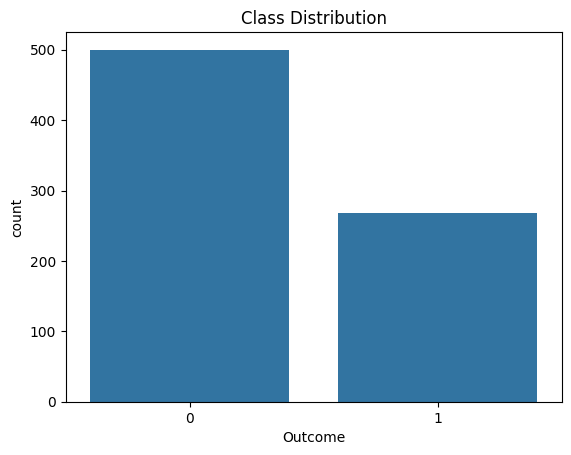

In [8]:
sns.countplot(x='Outcome', data=df_clean)
plt.title('Class Distribution')
plt.show()


- Non-diabetic patients (Class 0): 500 samples
- Diabetic patients (Class 1): 268 samples

The dataset contains more non-diabetic patients than diabetic patients, indicating a moderate class imbalance. However, the imbalance is not severe and the dataset remains suitable for training machine learning models.

### 1.5 Correlation Analysis

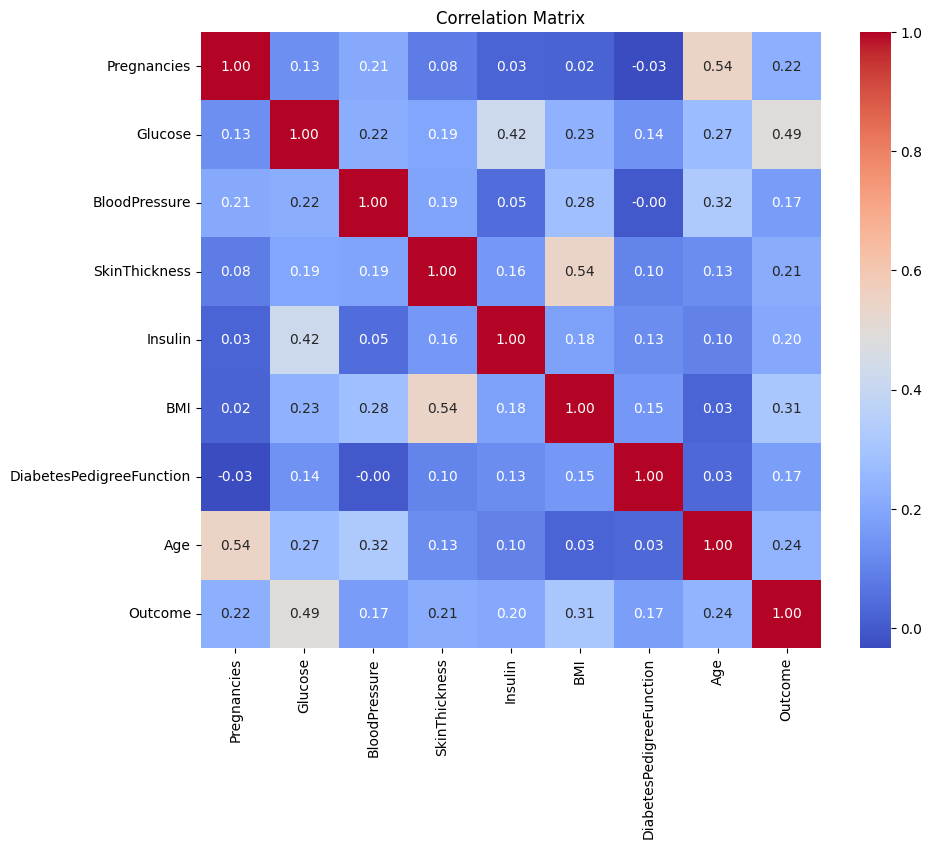

In [9]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df_clean.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

The results show that **Glucose (0.49)** has the strongest correlation with diabetes, followed by **BMI (0.31)** and **Age (0.24)**.

This indicates that these features are the most influential predictors of diabetes in the dataset.

## 2.Data Preparation for Modeling

### 2.1 Feature and Target Selection

In [10]:
# Features and target

X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (768, 8)
Target shape: (768,)


### 2.2 Train-Test Split

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 614
Testing samples: 154


### 2.3 Feature Scaling

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)

Training set shape: (614, 8)
Testing set shape: (154, 8)


## 3. Model Development

### 3.1 Support Vector Machine (SVM)


In [13]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

SVC(probability=True, random_state=42)

An SVM classifier with an RBF kernel was trained using the standardized training data. 

The RBF kernel was selected because it can capture nonlinear relationships between the input features and diabetes outcomes.

### 3.2 Hyperparameter Optimization

In [14]:
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:,1]

In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1-score :", f1_score(y_test, y_pred_svm))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_svm))

Accuracy : 0.7402597402597403
Precision: 0.6521739130434783
Recall   : 0.5555555555555556
F1-score : 0.6
ROC-AUC  : 0.7963888888888889


The SVM model achieved an accuracy of 74.03% and a ROC-AUC score of 79.64%. 

The model correctly identified most non-diabetic patients but missed some diabetic cases, resulting in a recall of 55.56%.

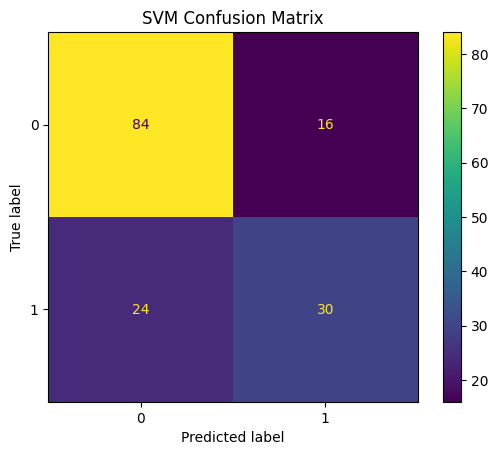

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("SVM Confusion Matrix")
plt.show()

The confusion matrix shows that the model correctly classified 84 non-diabetic patients and 30 diabetic patients. 

However, 24 diabetic patients were incorrectly classified as non-diabetic, indicating room for improvement in detecting positive cases.

TN = 84,
FP = 16,
FN = 24,
TP = 30

### 3.3 Artificial Neural Network (ANN)

In [17]:
from sklearn.neural_network import MLPClassifier

ann_model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

ann_model.fit(X_train_scaled, y_train)


MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=1000, random_state=42)

An Artificial Neural Network (ANN) was implemented using a Multi-Layer Perceptron (MLP) classifier. 

The network consisted of two hidden layers with 16 and 8 neurons, ReLU activation, and the Adam optimizer. 

The model was trained using the standardized training data and evaluated using several classification metrics.

In [18]:

y_pred_ann = ann_model.predict(X_test_scaled)
y_prob_ann = ann_model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_ann))
print("Precision:", precision_score(y_test, y_pred_ann))
print("Recall   :", recall_score(y_test, y_pred_ann))
print("F1-score :", f1_score(y_test, y_pred_ann))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_ann))

Accuracy : 0.7207792207792207
Precision: 0.5964912280701754
Recall   : 0.6296296296296297
F1-score : 0.6126126126126126
ROC-AUC  : 0.8187037037037037


The ANN model achieved an accuracy of 72.08%, a recall of 62.96%, and a ROC-AUC score of 81.87%.

Compared to the SVM model, the ANN achieved higher recall and ROC-AUC, indicating a better ability to identify diabetic patients.

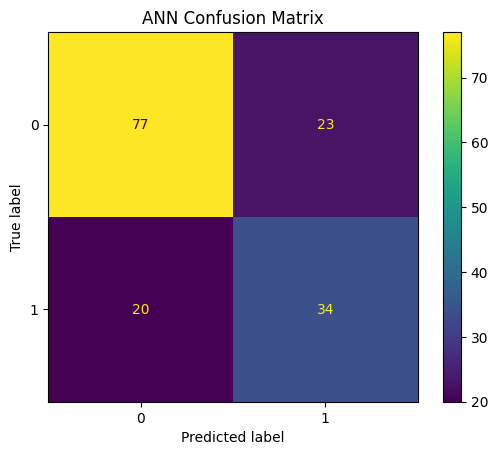

In [19]:
cm = confusion_matrix(y_test, y_pred_ann)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("ANN Confusion Matrix")
plt.show()


The confusion matrix shows that the ANN correctly classified 77 non-diabetic patients and 34 diabetic patients.

The model produced 20 false negatives and 23 false positives. Compared to the SVM model, the ANN detected more diabetic patients, which resulted in a higher recall score.

TN = 77,
FP = 23,
FN = 20,
TP = 34

### 3.4 Random Forest

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200, random_state=42)


A Random Forest classifier was implemented using 200 decision trees. 

Random Forest combines multiple decision trees to improve prediction stability and reduce overfitting. 

The model was trained using the training dataset and evaluated using standard classification metrics.

In [21]:

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1-score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.7402597402597403
Precision: 0.6521739130434783
Recall   : 0.5555555555555556
F1-score : 0.6
ROC-AUC  : 0.8161111111111111



The Random Forest model achieved an accuracy of 74.03%, an F1-score of 0.60, and a ROC-AUC score of 81.61%.

The model produced results similar to the SVM model while achieving a slightly higher ROC-AUC score.

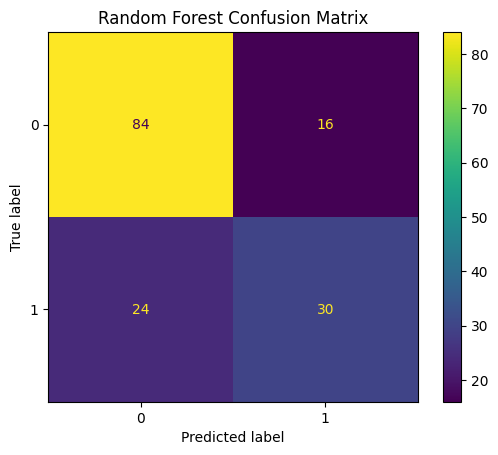

In [22]:
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()


The confusion matrix shows that the model correctly classified 84 non-diabetic patients and 30 diabetic patients.

The model misclassified 16 non-diabetic patients and 24 diabetic patients. Overall, the Random Forest model demonstrated stable performance in diabetes prediction.

TN = 84,
FP = 16,
FN = 24,
TP = 30

**note**: The Random Forest and SVM models produced identical confusion matrices, indicating that both models generated the same class predictions on the testing dataset. However, the Random Forest achieved a slightly higher ROC-AUC score due to differences in probability estimation.

### Feature importance


Random Forest feature importance was used to determine which features contributed most to diabetes prediction. 

Higher importance values indicate a greater influence on the model's decisions.

In [23]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                    Feature  Importance
1                   Glucose    0.268355
5                       BMI    0.158066
6  DiabetesPedigreeFunction    0.124386
7                       Age    0.120345
4                   Insulin    0.092340
2             BloodPressure    0.083938
0               Pregnancies    0.079370
3             SkinThickness    0.073200



The results show that **Glucose** is the most important feature for predicting diabetes, followed by **BMI**, **DiabetesPedigreeFunction**, and **Age**.

The least important features were **SkinThickness**, **Pregnancies**, and **BloodPressure**.

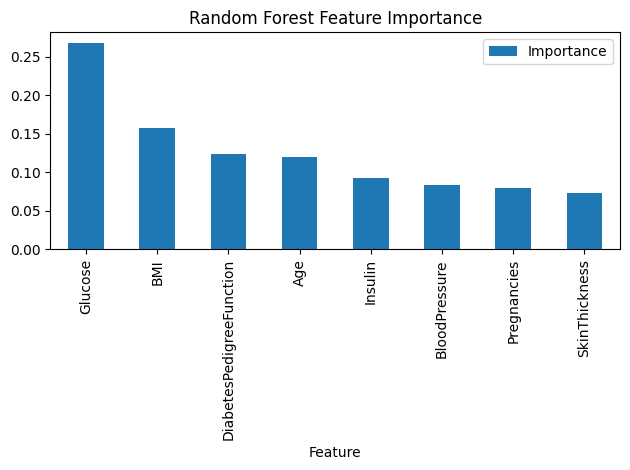

In [24]:
import matplotlib.pyplot as plt

feature_importance.plot(
    x='Feature',
    y='Importance',
    kind='bar'
)

plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

### Observation

The feature importance plot confirms that Glucose has the strongest impact on diabetes prediction. This finding is consistent with the correlation analysis, where Glucose also showed the highest correlation with the target variable.

Based on these results, the top four features (Glucose, BMI, DiabetesPedigreeFunction, and Age) were selected for the feature selection experiment.

### 3.5 Voting Ensemble


A Voting Ensemble classifier was created by combining the SVM, ANN, and Random Forest models. Soft voting was used, meaning that the predicted probabilities from all models were averaged to make the final prediction.

**The goal** was to improve overall performance by leveraging the strengths of multiple classifiers.

In [25]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[
        ('svm', svm_model),
        ('ann', ann_model),
        ('rf', rf_model)
    ],
    voting='soft'
)

voting_model.fit(X_train_scaled, y_train)

VotingClassifier(estimators=[('svm', SVC(probability=True, random_state=42)),
                             ('ann',
                              MLPClassifier(hidden_layer_sizes=(16, 8),
                                            max_iter=1000, random_state=42)),
                             ('rf',
                              RandomForestClassifier(n_estimators=200,
                                                     random_state=42))],
                 voting='soft')

In [26]:
y_pred_vote = voting_model.predict(X_test_scaled)
y_prob_vote = voting_model.predict_proba(X_test_scaled)[:, 1]

In [27]:
print("Accuracy :", accuracy_score(y_test, y_pred_vote))
print("Precision:", precision_score(y_test, y_pred_vote))
print("Recall   :", recall_score(y_test, y_pred_vote))
print("F1-score :", f1_score(y_test, y_pred_vote))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_vote))

Accuracy : 0.7402597402597403
Precision: 0.64
Recall   : 0.5925925925925926
F1-score : 0.6153846153846154
ROC-AUC  : 0.8175925925925926



The Voting Ensemble achieved an accuracy of 74.03%, an F1-score of 0.615, and a ROC-AUC score of 81.76%.

Among all evaluated models, the Voting Ensemble achieved the highest F1-score while maintaining strong overall accuracy, demonstrating the effectiveness of combining multiple machine learning models.

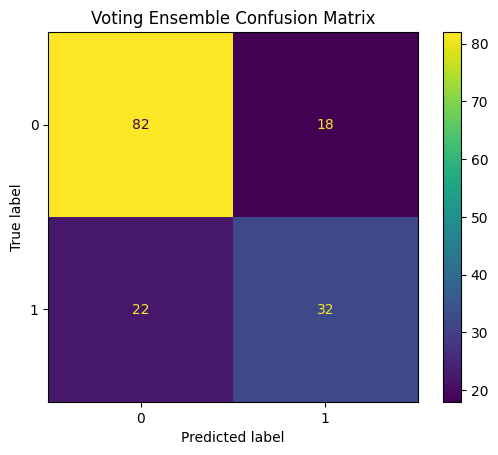

In [28]:
cm = confusion_matrix(y_test, y_pred_vote)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Voting Ensemble Confusion Matrix")
plt.show()


The confusion matrix shows that the model correctly classified 82 non-diabetic patients and 32 diabetic patients.

TN = 82,
FP = 18,
FN = 22,
TP = 32

Compared to the SVM and Random Forest models, the Voting Ensemble reduced false negatives and improved recall, resulting in better overall classification performance.


The Voting Ensemble produced the **best overall balance** between accuracy, recall, and F1-score. Therefore, it was selected as the final model for diabetes prediction.

## 4. feature selection experiment


Feature selection was performed using the Random Forest feature importance results. The four most important features were selected:

- Glucose
- BMI
- DiabetesPedigreeFunction
- Age

The objective was to investigate whether reducing the number of features could maintain model performance while simplifying the model.

In [29]:
selected_features = [
    'Glucose',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

X_selected = df_clean[selected_features]
y_selected = df_clean['Outcome']

print(X_selected.head())

   Glucose   BMI  DiabetesPedigreeFunction  Age
0    148.0  33.6                     0.627   50
1     85.0  26.6                     0.351   31
2    183.0  23.3                     0.672   32
3     89.0  28.1                     0.167   21
4    137.0  43.1                     2.288   33



The selected features were separated from the target variable and divided into training and testing sets using an 80:20 split. 

Feature scaling was then applied using StandardScaler before training the SVM model.

In [30]:
X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X_selected,
    y_selected,
    test_size=0.2,
    random_state=42,
    stratify=y_selected
)


An SVM classifier was trained using only the four selected features.

The model was evaluated using the same metrics as the previous experiments to compare its performance with the full-feature model.

In [31]:
scaler_fs = StandardScaler()

X_train_fs_scaled = scaler_fs.fit_transform(X_train_fs)
X_test_fs_scaled = scaler_fs.transform(X_test_fs)

**Train SVM on Selected Features**


In [32]:
svm_fs = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm_fs.fit(X_train_fs_scaled, y_train_fs)

y_pred_svm_fs = svm_fs.predict(X_test_fs_scaled)
y_prob_svm_fs = svm_fs.predict_proba(X_test_fs_scaled)[:, 1]

print("Accuracy :", accuracy_score(y_test_fs, y_pred_svm_fs))
print("Precision:", precision_score(y_test_fs, y_pred_svm_fs))
print("Recall   :", recall_score(y_test_fs, y_pred_svm_fs))
print("F1-score :", f1_score(y_test_fs, y_pred_svm_fs))
print("ROC-AUC  :", roc_auc_score(y_test_fs, y_prob_svm_fs))

Accuracy : 0.7402597402597403
Precision: 0.675
Recall   : 0.5
F1-score : 0.574468085106383
ROC-AUC  : 0.7984259259259259



Using only the selected features, the SVM model achieved:

- Accuracy: 74.03%
- Precision: 67.50%
- Recall: 50.00%
- F1-score: 57.45%
- ROC-AUC: 79.84%

The reduced feature set maintained the same accuracy as the original model and slightly improved precision. However, recall and F1-score decreased, indicating that some useful information was lost when removing features.

Therefore, the full feature set was retained for the final model.

## 5. Results and Discussion

| Model           | Features          | Accuracy  | Precision | Recall | F1        | ROC-AUC |
| --------------- | ----------------- | --------- | --------- | ------ | --------- | ------- |
| SVM             | All Features      | 0.740     | 0.652     | 0.556  | 0.600     | 0.796   |
| SVM             | Selected Features | 0.740     | 0.675     | 0.500  | 0.574     | 0.798   |
| ANN             | All Features      | 0.721     | 0.597     | 0.630  | 0.613     | 0.819   |
| Random Forest   | All Features      | 0.740     | 0.652     | 0.556  | 0.600     | 0.816   |
| Voting Ensemble | All Features      | **0.740** | 0.640     | 0.593  | **0.615** | 0.818   |


---